## Import Libraries

In [57]:
import pandas as pd
from math import sin, cos, pi
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns

## Data analysis and preparation

In [58]:
# Read the CSV file into a DataFrame
df = pd.read_csv("C:/Users/9000639/Documents/CQ_SerieTemporal/temporal-series-analysis/data/Projeto_CQ.csv", sep=";")
df.head()

,Ano,Mês,Estoque_inicial,Consumo_mensal,Compras
0,2023,1,307.0,30.0,0.0
1,2023,2,277.0,24.0,0.0
2,2023,3,253.0,33.0,0.0
3,2023,4,220.0,41.0,0.0
4,2023,5,179.0,75.0,0.0


In [59]:
# Data correlation analysis
# ADF Test
adf_result = adfuller(df["Consumo_mensal"].dropna())
p_value = adf_result[1]
print(f"Estatística ADF: {adf_result[0]:.4f}")
print(f"p-valor: {p_value:.6f}")

Estatística ADF: -2.5289
p-valor: 0.108609


C:\Users\9000639\AppData\Local\Temp\ipykernel_28384\4113828935.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df["Consumo_mensal"].dropna())


In [60]:
# Due to ADF test results, we can conclude that the time series is non-stationary. Therefore, we will apply differencing to make it stationary.
df["Consumo_mensal_diff"] = df["Consumo_mensal"].diff()
# ADF Test
adf_result = adfuller(df["Consumo_mensal_diff"].dropna())
p_value = adf_result[1]
print(f"Estatística ADF série diferenciada: {adf_result[0]:.4f}")
print(f"p-valor: {p_value:.6f}")

Estatística ADF série diferenciada: -6.0632
p-valor: 0.000000


C:\Users\9000639\AppData\Local\Temp\ipykernel_28384\3455068931.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df["Consumo_mensal_diff"].dropna())


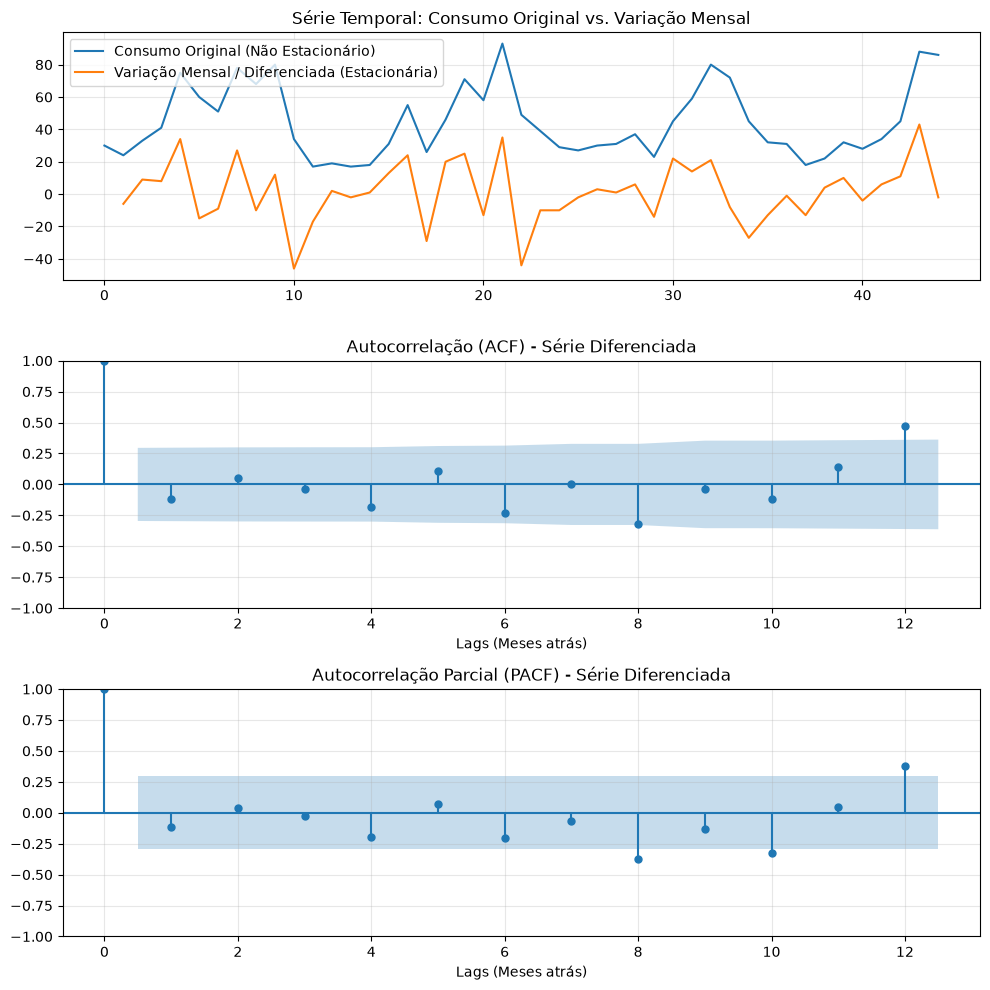

In [61]:
# Visualization of the original and differenced series, along with ACF and PACF plots
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Consumption vs Diff
axes[0].plot(df['Consumo_mensal'], label='Consumo Original (Não Estacionário)', color='tab:blue')
axes[0].plot(df['Consumo_mensal_diff'], label='Variação Mensal / Diferenciada (Estacionária)', color='tab:orange')
axes[0].set_title('Série Temporal: Consumo Original vs. Variação Mensal', fontsize=12)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# ACF of Differenced Series
plot_acf(df['Consumo_mensal_diff'].dropna(), ax=axes[1], lags=12, alpha=0.05)
axes[1].set_title('Autocorrelação (ACF) - Série Diferenciada', fontsize=12)
axes[1].set_xlabel('Lags (Meses atrás)')
axes[1].grid(True, alpha=0.3)

# PACF of Differenced Series
plot_pacf(df['Consumo_mensal_diff'].dropna(), ax=axes[2], lags=12, alpha=0.05, method='ywm')
axes[2].set_title('Autocorrelação Parcial (PACF) - Série Diferenciada', fontsize=12)
axes[2].set_xlabel('Lags (Meses atrás)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
# Create new features based on the month and lagged values of the consumption
df["Month_sen"] = [sin(2*pi*month/12) for month in df["Mês"]]
df["Month_cos"] = [cos(2*pi*month/12) for month in df["Mês"]]
df["Lag1"] = df["Consumo_mensal"].shift(1)
df["Lag2"] = df["Consumo_mensal"].shift(2)
df["Lag8"] = df["Consumo_mensal"].shift(8)
df["Lag10"] = df["Consumo_mensal"].shift(10)
df["Moving_Average_3_Months"] = df["Consumo_mensal"].rolling(window=3).mean()
df["Moving_Average_6_Months"] = df["Consumo_mensal"].rolling(window=6).mean()
df["Moving_Average_12_Months"] = df["Consumo_mensal"].rolling(window=12).mean()
df["Trend"] = (df["Lag1"] - df["Lag2"]) / df["Lag2"]
df.head()

,Ano,Mês,Estoque_inicial,Consumo_mensal,Compras,Consumo_mensal_diff,Month_sen,Month_cos,Lag1,Lag2,Lag8,Lag10,Moving_Average_3_Months,Moving_Average_6_Months,Moving_Average_12_Months,Trend
0,2023,1,307.0,30.0,0.0,NaN,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,2,277.0,24.0,0.0,-6.0,0.866025,5.000000e-01,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,3,253.0,33.0,0.0,9.0,1.000000,6.123234e-17,24.0,30.0,NaN,NaN,29.000000,NaN,NaN,-0.200000
3,2023,4,220.0,41.0,0.0,8.0,0.866025,-5.000000e-01,33.0,24.0,NaN,NaN,32.666667,NaN,NaN,0.375000
4,2023,5,179.0,75.0,0.0,34.0,0.500000,-8.660254e-01,41.0,33.0,NaN,NaN,49.666667,NaN,NaN,0.242424


array([[<Axes: xlabel='Ano', ylabel='Ano'>,
        <Axes: xlabel='Mês', ylabel='Ano'>,
        <Axes: xlabel='Estoque_inicial', ylabel='Ano'>,
        <Axes: xlabel='Consumo_mensal', ylabel='Ano'>,
        <Axes: xlabel='Compras', ylabel='Ano'>,
        <Axes: xlabel='Consumo_mensal_diff', ylabel='Ano'>,
        <Axes: xlabel='Month_sen', ylabel='Ano'>,
        <Axes: xlabel='Month_cos', ylabel='Ano'>,
        <Axes: xlabel='Lag1', ylabel='Ano'>,
        <Axes: xlabel='Lag2', ylabel='Ano'>,
        <Axes: xlabel='Lag8', ylabel='Ano'>,
        <Axes: xlabel='Lag10', ylabel='Ano'>,
        <Axes: xlabel='Moving_Average_3_Months', ylabel='Ano'>,
        <Axes: xlabel='Moving_Average_6_Months', ylabel='Ano'>,
        <Axes: xlabel='Moving_Average_12_Months', ylabel='Ano'>,
        <Axes: xlabel='Trend', ylabel='Ano'>],
       [<Axes: xlabel='Ano', ylabel='Mês'>,
        <Axes: xlabel='Mês', ylabel='Mês'>,
        <Axes: xlabel='Estoque_inicial', ylabel='Mês'>,
        <Axes: xlabel='Consu

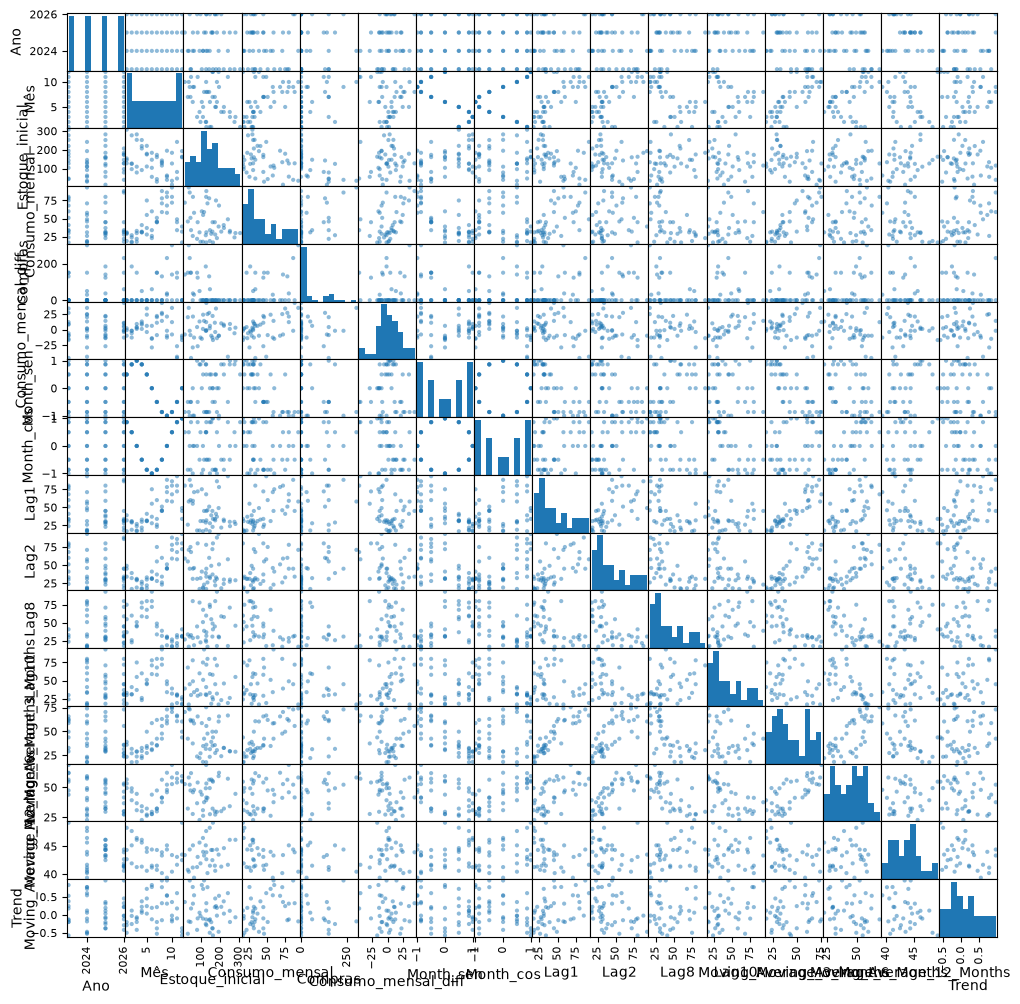

In [63]:
# Analyze the data
pd.plotting.scatter_matrix(df, figsize=(12, 12))

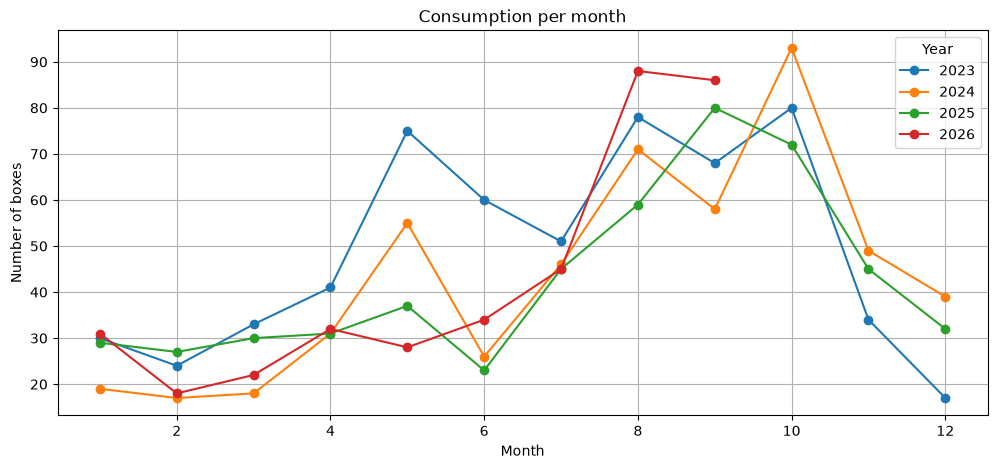

In [64]:
df_grouped = df.groupby("Ano")
plt.figure(figsize=(12,5))
for label, df_ in df_grouped:
    plt.plot(df_["Mês"], df_["Consumo_mensal"], marker='o', label=label)
plt.title('Consumption per month')
plt.xlabel('Month')
plt.ylabel('Number of boxes')
plt.legend(title='Year')
plt.grid(True)
plt.show()

<Axes: >

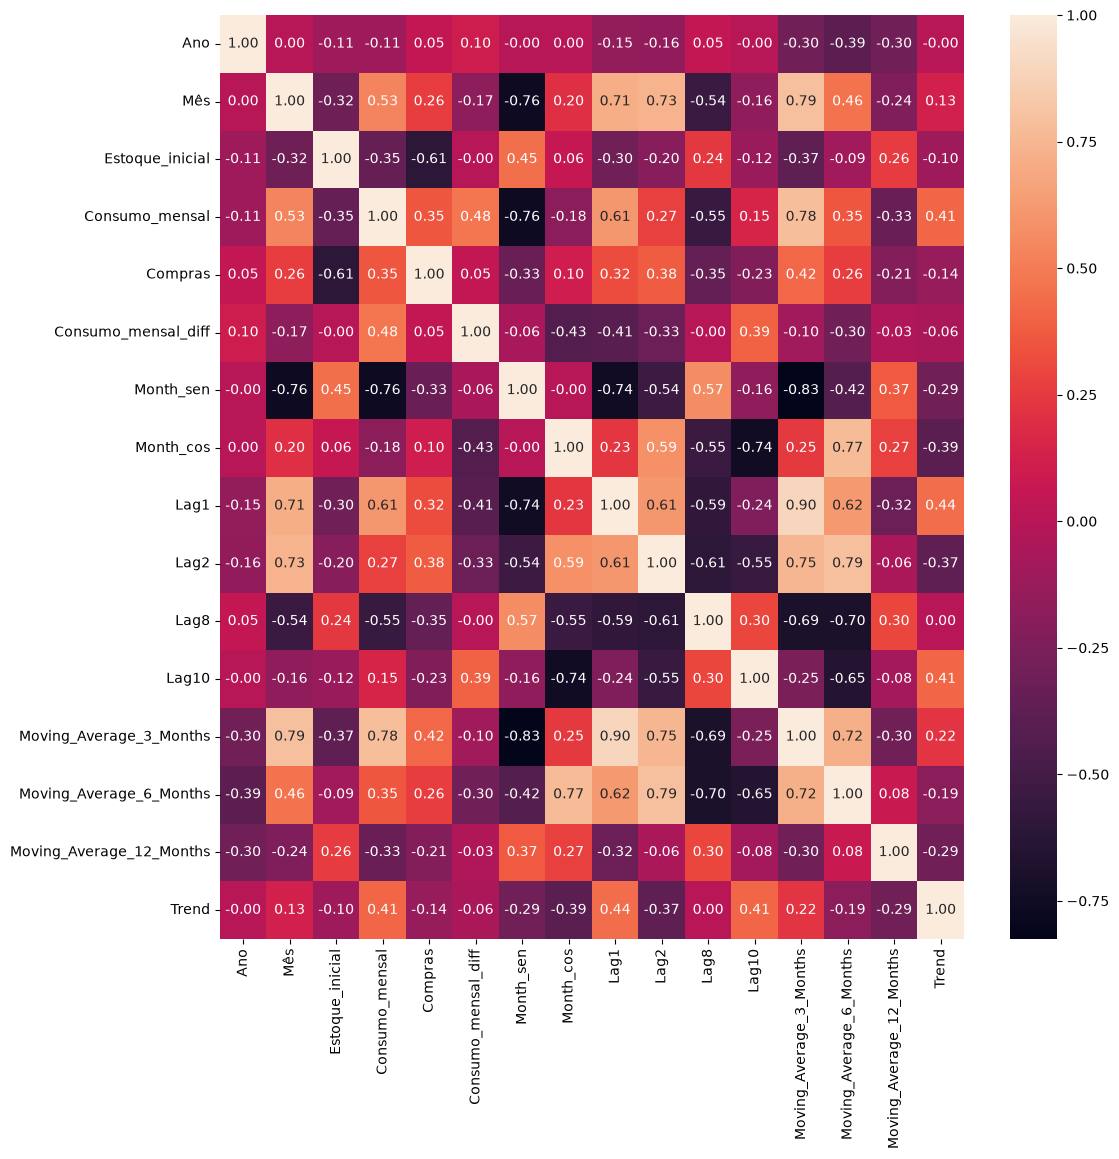

In [65]:
# Correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")